In [30]:
import sdv
import pandas as pd

from pathlib import Path

FIGURE_DIR = Path("../../book/book/images")

In [31]:
df_demographics = pd.read_csv('https://raw.githubusercontent.com/IanEisenberg/Self_Regulation_Ontology/refs/heads/master/Data/Complete_02-16-2019/demographics.csv', index_col=0).replace({'Sex': {0: 'Male', 1: 'Female'}})
variables_of_interest = ['Sex', 'Age', 'HighestEducation', 
       'HeightInches', 'WeightPounds','ArrestedChargedLifeCount',
       'CoffeeCupsPerDay', 'HouseholdIncome']
df_demographics = df_demographics[variables_of_interest]

df_measures = pd.read_csv('https://raw.githubusercontent.com/IanEisenberg/Self_Regulation_Ontology/refs/heads/master/Data/Complete_02-16-2019/meaningful_variables_clean.csv', index_col=0)
measures_of_interest = [
       'upps_impulsivity_survey.lack_of_perseverance',
       'upps_impulsivity_survey.lack_of_premeditation',
       'upps_impulsivity_survey.negative_urgency',
       'upps_impulsivity_survey.positive_urgency',
       'upps_impulsivity_survey.sensation_seeking',
        'ten_item_personality_survey.agreeableness',
       'ten_item_personality_survey.conscientiousness.ReflogTr',
       'ten_item_personality_survey.emotional_stability',
       'ten_item_personality_survey.extraversion',
       'ten_item_personality_survey.openness',
       'ravens.score',
       'cognitive_reflection_survey.correct_proportion'
]
df_measures = df_measures[measures_of_interest]
df_orig = df_demographics.join(df_measures, how='inner')


df_orig.head() 

,Sex,Age,HighestEducation,HeightInches,WeightPounds,ArrestedChargedLifeCount,CoffeeCupsPerDay,HouseholdIncome,upps_impulsivity_survey.lack_of_perseverance,upps_impulsivity_survey.lack_of_premeditation,upps_impulsivity_survey.negative_urgency,upps_impulsivity_survey.positive_urgency,upps_impulsivity_survey.sensation_seeking,ten_item_personality_survey.agreeableness,ten_item_personality_survey.conscientiousness.ReflogTr,ten_item_personality_survey.emotional_stability,ten_item_personality_survey.extraversion,ten_item_personality_survey.openness,ravens.score,cognitive_reflection_survey.correct_proportion
s001,Female,27,3,62,110,0.0,1.0,40000.0,1.5,1.909091,1.583333,2.142857,3.416667,4.5,0.916291,6.0,3.5,6.0,2.0,0.166667
s002,Male,35,2,72,240,0.0,3.0,19500.0,1.5,2.090909,3.000000,3.285714,3.083333,6.0,1.386294,6.0,5.0,6.5,4.0,0.166667
s003,Male,25,4,73,185,0.0,1.0,60000.0,2.4,2.363636,3.000000,2.785714,2.833333,5.5,0.916291,5.0,4.5,5.0,3.0,0.666667
s004,Male,35,4,71,190,0.0,0.0,81000.0,1.5,1.636364,1.583333,1.142857,1.916667,6.5,0.000000,7.0,3.0,4.0,9.0,0.666667
s005,Male,36,3,76,175,5.0,0.0,36000.0,1.7,1.363636,1.750000,1.000000,2.833333,6.0,1.098612,7.0,3.0,6.0,14.0,0.833333


### Negative controls

In [32]:
import anndata as ad
from pathlib import Path

In [33]:
datadir = Path('/Users/poldrack/data_unsynced/BCBS/immune_aging')
datafile = datadir / 'wf_snakemake/checkpoints/dataset-OneK1K_step-07_desc-pseudobulk.h5ad'

adata = ad.read_h5ad(datafile)
adata

AnnData object with n_obs × n_vars = 4635 × 29515
    obs: 'cell_type', 'donor_id', 'n_cells', 'development_stage', 'sex', 'age', 'total_counts'

In [34]:
# filter by cell type
cell_type = 'central memory CD4-positive, alpha-beta T cell'
adata_ct = adata[adata.obs['cell_type'] == cell_type, :].copy()
adata_df = adata_ct.to_df()

# filter out subjects with low number of cells
n_cells_threshold = 100
sample_sums = adata_ct.obs['n_cells']
adata_df = adata_df.loc[sample_sums[sample_sums >= n_cells_threshold].index, :]
print('excluded samples:', sum(sample_sums < n_cells_threshold))

# filter out genes that are zero in any samples
gene_filter = (adata_df == 0).sum(axis=0) == 0
adata_df = adata_df.loc[:, gene_filter] 
adata_df['age'] = adata_ct.obs.loc[adata_df.index, 'age']
# label under 40 and over 70
adata_df['age_group'] = pd.cut(adata_df['age'], bins=[0, 40, 80, 120], labels=['under_40', '40_to_70', 'over_80'])
# remove age group '40_to_70' to have a clearer contrast
adata_df = adata_df[adata_df['age_group'] != '40_to_70']
adata_df.age_group.value_counts()

excluded samples: 17


age_group
under_40    112
over_80     111
40_to_70      0
Name: count, dtype: int64

In [36]:
adata_df.to_parquet(datadir / 'control_experiment_central_memory_CD4_T_cells.parquet')

In [119]:
adata_df = pd.read_parquet(datadir / 'control_experiment_central_memory_CD4_T_cells.parquet')
# subsample from each group to have balanced classes
n_per_class = 18
adata_df = pd.concat([
    adata_df[adata_df['age_group'] == 'under_40'].sample(n_per_class, random_state=42),
    adata_df[adata_df['age_group'] == 'over_80'].sample(n_per_class, random_state=42)
])

adata_df.shape


(36, 4214)

set up predictive model using a randomly generated disease outcome.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate, StratifiedShuffleSplit
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier as KNN
from tqdm import tqdm
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import balanced_accuracy_score


def run_classifier_simple(X, y, model, cv, shuffle_y=False, 
                    scores=None, rng=None):
    if shuffle_y:
        if rng is None:
            rng = np.random.default_rng()
        y = rng.permutation(y)
    if scores is None:
        scores = ['roc_auc', 'balanced_accuracy']

    result = cross_validate(model, X, y, cv=cv, scale_X=True,
                    scoring=('roc_auc', 'balanced_accuracy'),
                    return_train_score=True)
    means = {f'{k}': np.mean(v) for k, v in result.items() if k.startswith('test_')}
    means.update({f'{k}': np.mean(v) for k, v in result.items() if k.startswith('train_')})
    return means


def run_classifier(X, y, model, cv, shuffle_y=False, 
                    scorer=None, rng=None, scale_X=True,
                    nfeatures_to_select=10,
                    bad_feature_selection=False):
    """
    Run a classifier with cross-validation, optionally shuffling the target labels.
    also do scaling and feature selection within each fold
    """
    if shuffle_y:
        if rng is None:
            rng = np.random.default_rng()
        y = rng.permutation(y)

    if scorer is None:
        scorer = balanced_accuracy_score

    if bad_feature_selection:
        # feature selection outside of CV (this is bad practice)
        selector = f_classif
        f_values, p_values = selector(X, y)
        top_k_indices = np.argsort(f_values)[-nfeatures_to_select:]
        X = X[:, top_k_indices]

    results = {}
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if scale_X:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
 
        if nfeatures_to_select is not None and not bad_feature_selection:
            # feature selection using ANOVA F-test
            selector = f_classif
            f_values, p_values = selector(X_train, y_train)
            # select top 100 features
            top_k_indices = np.argsort(f_values)[-nfeatures_to_select:]

            X_train = X_train[:, top_k_indices]
            X_test = X_test[:, top_k_indices]

       
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_train = model.predict(X_train)

        score_value = scorer(y_test, y_pred)
        train_score_value = scorer(y_train, y_pred_train)
        scorer_name = scorer.__name__.replace('_score', '')
        if f'test_{scorer_name}' not in results:
            results[f'test_{scorer_name}'] = [] 
        results[f'test_{scorer_name}'].append(score_value)
        if f'train_{scorer_name}' not in results:
            results[f'train_{scorer_name}'] = []
        results[f'train_{scorer_name}'].append(train_score_value)

    # compute mean scores across folds
    means = {k: np.mean(v) for k, v in results.items()}
    return means

n_simulations = 5000
results = []
results_bad_fs = []

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.4, 
    random_state=42)

model = SGDClassifier(loss='hinge', random_state=42)
model = LinearSVC(random_state=42)

over80 = (adata_df['age_group'].values == 'over_80').astype(int)
X = adata_df.drop(columns=['age', 'age_group']).to_numpy()
# do feature selection using VarianceThreshold


y = over80

print('True results:')
true_result = run_classifier(X, y, model, cv,
        shuffle_y=False, rng=rng)
print(f'True balanced_accuracy: {true_result["test_balanced_accuracy"]:.3f}')
true_result_bad_fs = run_classifier(X, y, model, cv,
        shuffle_y=False, rng=rng,
        bad_feature_selection=True)
print('True results with bad feature selection:')
print(f'True balanced_accuracy: {true_result_bad_fs["test_balanced_accuracy"]:.3f}')

for i in tqdm(range(n_simulations)):
    proportion_positive = 0.5
    # random binary target
    rng = np.random.default_rng() #i)
    #y = rng.choice([0, 1], size=n_samples, 
    #    p=[1 - proportion_positive, proportion_positive])

    results.append(run_classifier(X, y, model, cv,
        shuffle_y=True, rng=rng))
    results_bad_fs.append(run_classifier(X, y, model, cv,
        shuffle_y=True, rng=rng,
        bad_feature_selection=True))

results_df = pd.DataFrame(results)
results_bad_fs_df = pd.DataFrame(results_bad_fs)


method = 'balanced_accuracy'
rand_pval = 1 - np.mean(true_result[f"test_{method}"] > results_df[f'test_{method}'])
print(f'\np-value for {method}: {rand_pval:.3f}')
print(f'Shuffled {method}: mean={results_df[f"test_{method}"].mean():.3f}, std={results_df[f"test_{method}"].std():.3f}')
print(f'Shuffled {method} with bad feature selection: mean={results_bad_fs_df[f"test_{method}"].mean():.3f}, std={results_bad_fs_df[f"test_{method}"].std():.3f}')
print(f'Shuffled training {method}: mean={results_df[f"train_{method}"].mean():.3f}, std={results_df[f"train_{method}"].std():.3f}')

# t-test verus 0.5 for balanced accuracy on shuffled data with and without bad feature selection

from scipy.stats import ttest_1samp
tstat, pval = ttest_1samp(results_df[f'test_{method}'], 0.5)
print(f'T-test versus 0.5 for balanced accuracy on shuffled data with valid feature selection: t={tstat:.3f}, p={pval:.3f}')
tstat, pval = ttest_1samp(results_bad_fs_df[f'test_{method}'], 0.5)
print(f'T-test versus 0.5 for balanced accuracy on shuffled data with bad feature selection: t={tstat:.3f}, p={pval:.3f}')


True results:
True balanced_accuracy: 0.575
True results with bad feature selection:
True balanced_accuracy: 0.620


 35%|███▍      | 872/2500 [00:16<00:31, 51.60it/s]

In [129]:
results_bad_fs
from scipy.stats import ttest_1samp
tstat, pval = ttest_1samp(results_df[f'test_{method}'], 0.5)
print(f'T-test versus 0.5 for balanced accuracy on shuffled data without bad feature selection: t={tstat:.3f}, p={pval:.3f}')
tstat, pval = ttest_1samp(results_bad_fs_df[f'test_{method}'], 0.5)
print(f'T-test versus 0.5 for balanced accuracy on shuffled data with bad feature selection: t={tstat:.3f}, p={pval:.3f}')

T-test versus 0.5 for balanced accuracy on shuffled data without bad feature selection: t=-0.120, p=0.904
T-test versus 0.5 for balanced accuracy on shuffled data with bad feature selection: t=30.703, p=0.000


In [86]:
X_var = np.var(X, axis=0)
np.sort(X_var)[:100]

array([17.79681876, 22.47400913, 24.02493515, 25.44780711, 25.47097267,
       26.33055159, 26.83400028, 26.99221782, 27.18172495, 27.37991916,
       27.93408273, 27.99042812, 28.82185445, 28.87088017, 29.19451427,
       29.60731163, 29.68207686, 29.70114018, 30.33678538, 30.53485894,
       30.72585413, 30.96744354, 31.34895132, 31.35916668, 31.43666673,
       32.50308673, 32.69030143, 33.33411088, 33.66739729, 33.71481429,
       33.80007641, 33.81515816, 34.1724547 , 34.36606407, 34.51507169,
       34.68024694, 35.04321422, 35.41639687, 35.94823946, 35.99670213,
       36.0138752 , 36.40378853, 37.04976975, 37.131734  , 37.18546522,
       37.26948058, 37.30382674, 37.3529329 , 37.36676788, 38.33803213,
       38.36529993, 38.99949728, 39.03782501, 39.56102073, 39.56323272,
       39.74373102, 39.85256088, 39.91505962, 40.26382996, 40.28233023,
       40.81783265, 41.14524724, 41.53777474, 41.6007561 , 41.64765026,
       41.84841843, 42.02203945, 42.19586157, 42.27983671, 42.47

Text(0.5, 0, 'Balanced Accuracy')

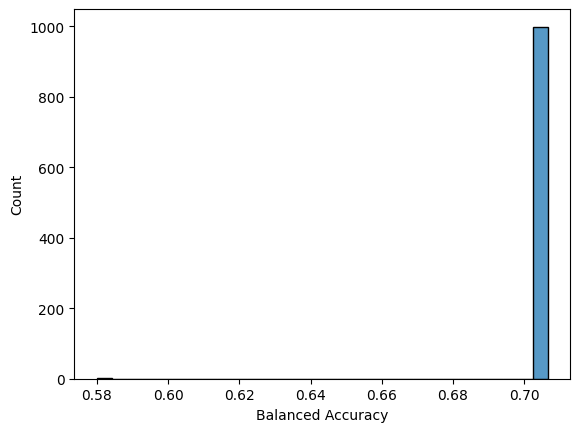

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(balanced_accuracy, bins=30)
plt.xlabel('Balanced Accuracy')

In [ ]:
y.mean()

np.float64(0.2989010989010989)